# Multi-Task


## 1. Install

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip install -q kaggle

from google.colab import files
print("kaggle.json:")
files.upload()

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

!kaggle datasets download -d aryashah2k/breast-ultrasound-images-dataset
!unzip -q breast-ultrasound-images-dataset.zip -d bus_dataset/

print("Complete!")

kaggle.json:


Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/aryashah2k/breast-ultrasound-images-dataset
License(s): CC0-1.0
100% 195M/195M [00:01<00:00, 184MB/s]

Complete!


In [3]:
!pip uninstall -y albumentations albucore
!pip install albumentations==1.4.7 opencv-python-headless==4.10.0.84
!pip install segmentation-models-pytorch
!pip install optuna plotly

Found existing installation: albumentations 2.0.8
Uninstalling albumentations-2.0.8:
  Successfully uninstalled albumentations-2.0.8
Found existing installation: albucore 0.0.24
Uninstalling albucore-0.0.24:
  Successfully uninstalled albucore-0.0.24
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 155.7/155.7 kB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 46.1 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.13.0.92
    Uninstalling opencv-python-headless-4.13.0.92:
      Successfully uninstalled opencv-python-headless-4.13.0.92
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 8.8 MB/s eta 0:00:00


## 2. Import

In [4]:
import os
import re
import cv2
import math
import time
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from glob import glob
from tqdm import tqdm
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import (
    accuracy_score, f1_score,
    confusion_matrix, classification_report,
    roc_curve, auc
)
from sklearn.preprocessing import label_binarize

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import albumentations as A
from albumentations.pytorch import ToTensorV2

import segmentation_models_pytorch as smp

import optuna
from optuna.samplers import TPESampler

optuna.logging.set_verbosity(optuna.logging.WARNING)
warnings.filterwarnings('ignore')

print("Import complete")

Import complete


## 3. Seed & Device

In [5]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


## 4. Load & Prepare data


In [6]:
ROOT = "/content/bus_dataset/Dataset_BUSI_with_GT"

for cls_name in ["normal", "benign", "malignant"]:
    cls_dir = os.path.join(ROOT, cls_name)
    print(cls_name, "->", len(os.listdir(cls_dir)))

normal -> 266
benign -> 891
malignant -> 421


In [7]:
CLASS_TO_ID = {"normal": 0, "benign": 1, "malignant": 2}
IMG_EXTS    = {".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff"}

def is_mask_file(filename):
    return "_mask" in filename.lower()

def get_base_key(filename):
    name, _ = os.path.splitext(filename)
    name = re.sub(r"_mask(_\d+)?$", "", name, flags=re.IGNORECASE)
    return name

records = []

for cls_name in ["normal", "benign", "malignant"]:
    cls_dir    = os.path.join(ROOT, cls_name)
    files_list = sorted(os.listdir(cls_dir))
    image_map, mask_map = {}, {}

    for f in files_list:
        ext = os.path.splitext(f)[1].lower()
        if ext not in IMG_EXTS:
            continue
        full_path = os.path.join(cls_dir, f)
        key = get_base_key(f)
        if is_mask_file(f):
            mask_map.setdefault(key, []).append(full_path)
        else:
            image_map[key] = full_path

    for key, img_path in image_map.items():
        records.append({
            "image_path": img_path,
            "mask_paths": sorted(mask_map.get(key, [])),
            "class_name": cls_name,
            "class_id":   CLASS_TO_ID[cls_name]
        })

df = pd.DataFrame(records)
print("Total samples:", len(df))
display(df.head())
print(df["class_name"].value_counts())

Total samples: 780


,image_path,mask_paths,class_name,class_id
0,/content/bus_dataset/Dataset_BUSI_with_GT/norm...,[/content/bus_dataset/Dataset_BUSI_with_GT/nor...,normal,0
1,/content/bus_dataset/Dataset_BUSI_with_GT/norm...,[/content/bus_dataset/Dataset_BUSI_with_GT/nor...,normal,0
2,/content/bus_dataset/Dataset_BUSI_with_GT/norm...,[/content/bus_dataset/Dataset_BUSI_with_GT/nor...,normal,0
3,/content/bus_dataset/Dataset_BUSI_with_GT/norm...,[/content/bus_dataset/Dataset_BUSI_with_GT/nor...,normal,0
4,/content/bus_dataset/Dataset_BUSI_with_GT/norm...,[/content/bus_dataset/Dataset_BUSI_with_GT/nor...,normal,0


class_name
benign       437
malignant    210
normal       133
Name: count, dtype: int64


In [8]:

train_val_df, test_df = train_test_split(
    df, test_size=0.15, random_state=42, stratify=df["class_id"]
)
train_val_df = train_val_df.reset_index(drop=True)
test_df      = test_df.reset_index(drop=True)

print("Train+Val:", len(train_val_df))
print(train_val_df["class_name"].value_counts(), "\n")
print("Test (hold-out):", len(test_df))
print(test_df["class_name"].value_counts())

Train+Val: 663
class_name
benign       371
malignant    179
normal       113
Name: count, dtype: int64 

Test (hold-out): 117
class_name
benign       66
malignant    31
normal       20
Name: count, dtype: int64


## 5. Augmentation & Dataset

In [9]:
IMG_SIZE = 256

train_tfms = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.2),
    A.RandomRotate90(p=0.3),
    A.ShiftScaleRotate(
        shift_limit=0.05, scale_limit=0.10, rotate_limit=15,
        border_mode=cv2.BORDER_CONSTANT, p=0.4
    ),
    A.RandomBrightnessContrast(p=0.2),
    A.GaussNoise(p=0.15),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2()
])

valid_tfms = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2()
])

In [10]:
class BUSIMultiTaskDataset(Dataset):
    def __init__(self, df, transforms=None):
        self.df         = df.reset_index(drop=True)
        self.transforms = transforms

    def __len__(self):
        return len(self.df)

    def _read_image(self, path):
        img = cv2.imread(path)
        return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    def _read_and_merge_masks(self, mask_paths, image_shape):
        h, w   = image_shape[:2]
        merged = np.zeros((h, w), dtype=np.uint8)
        for mp in mask_paths:
            m = cv2.imread(mp, cv2.IMREAD_GRAYSCALE)
            if m is None:
                continue
            merged = np.maximum(merged, (m > 0).astype(np.uint8))
        return merged

    def __getitem__(self, idx):
        row      = self.df.iloc[idx]
        image    = self._read_image(row["image_path"])
        class_id = int(row["class_id"])

        mask_paths = row["mask_paths"]
        mask = (
            self._read_and_merge_masks(mask_paths, image.shape)
            if len(mask_paths) > 0
            else np.zeros(image.shape[:2], dtype=np.uint8)
        )

        if self.transforms:
            aug   = self.transforms(image=image, mask=mask)
            image = aug["image"]
            mask  = aug["mask"]

        mask  = mask.float().unsqueeze(0)           # [1, H, W]
        label = torch.tensor(class_id, dtype=torch.long)
        return image, mask, label

## 6. Model Arc


In [11]:
class MultiTaskUNet(nn.Module):
    def __init__(self, encoder_name="resnet34", encoder_weights="imagenet", num_classes=3):
        super().__init__()
        self.seg_model = smp.Unet(
            encoder_name=encoder_name,
            encoder_weights=encoder_weights,
            in_channels=3,
            classes=1
        )
        encoder_channels = self.seg_model.encoder.out_channels[-1]
        self.cls_head = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Dropout(0.3),
            nn.Linear(encoder_channels, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.2),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        features       = self.seg_model.encoder(x)
        decoder_output = self.seg_model.decoder(features)
        seg_logits     = self.seg_model.segmentation_head(decoder_output)
        cls_logits     = self.cls_head(features[-1])
        return seg_logits, cls_logits

## 7. Loss Functions & Metrics

> **Segmentation loss cố định**: `seg_loss = 0.5·BCE + 0.5·Dice`  
> **Total loss**: `alpha · cls_loss + (1 - alpha) · seg_loss`  
> **Optuna objective**: `Harmonic Mean(macro_f1, val_dice)`

In [12]:
# ── Dice Loss ──────────────────────────────────────────────────────────────
def dice_loss(logits, targets, smooth=1e-6):
    probs    = torch.sigmoid(logits).view(-1)
    targets  = targets.view(-1)
    inter    = (probs * targets).sum()
    return 1 - (2. * inter + smooth) / (probs.sum() + targets.sum() + smooth)

W_BCE_SEG  = 0.5
W_DICE_SEG = 0.5

def seg_loss_fixed(seg_logits, masks, bce_fn):

    return W_BCE_SEG * bce_fn(seg_logits, masks) + W_DICE_SEG * dice_loss(seg_logits, masks)

def harmonic_mean(a, b, eps=1e-8):
    return (2 * a * b) / (a + b + eps)

def dice_score_batch(logits, targets, threshold=0.5, smooth=1e-6):
    probs   = torch.sigmoid(logits)
    preds   = (probs > threshold).float()
    preds   = preds.view(preds.size(0), -1)
    targets = targets.view(targets.size(0), -1)
    inter   = (preds * targets).sum(dim=1)
    dice    = (2. * inter + smooth) / (preds.sum(dim=1) + targets.sum(dim=1) + smooth)
    return dice.mean().item()

def iou_score_batch(logits, targets, threshold=0.5, smooth=1e-6):
    probs   = torch.sigmoid(logits)
    preds   = (probs > threshold).float()
    preds   = preds.view(preds.size(0), -1)
    targets = targets.view(targets.size(0), -1)
    inter   = (preds * targets).sum(dim=1)
    union   = preds.sum(dim=1) + targets.sum(dim=1) - inter
    return ((inter + smooth) / (union + smooth)).mean().item()

print(f"Seg loss  : {W_BCE_SEG}·BCE + {W_DICE_SEG}·Dice")
print("Total loss       : alpha·cls + (1-alpha)·seg")
print("Optuna objective : MAXIMIZE Harmonic(macro_f1, dice)")

Seg loss  : 0.5·BCE + 0.5·Dice
Total loss       : alpha·cls + (1-alpha)·seg
Optuna objective : MAXIMIZE Harmonic(macro_f1, dice)


## 8. Training Loop

In [13]:
def run_epoch(model, loader, optimizer=None, train=True,
              alpha=0.5, bce_fn=None, ce_fn=None):

    model.train() if train else model.eval()

    total_loss     = 0.0
    total_seg_loss = 0.0
    total_cls_loss = 0.0
    total_dice     = 0.0
    total_iou      = 0.0
    all_preds      = []
    all_labels     = []

    pbar = tqdm(loader, desc="Train" if train else "Val  ", leave=False)

    for images, masks, labels in pbar:
        images = images.to(device, non_blocking=True)
        masks  = masks.to(device,  non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        with torch.set_grad_enabled(train):
            seg_logits, cls_logits = model(images)

            s_loss = seg_loss_fixed(seg_logits, masks, bce_fn)

            c_loss = ce_fn(cls_logits, labels)

            loss = alpha * c_loss + (1.0 - alpha) * s_loss

            if train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

        dice  = dice_score_batch(seg_logits.detach(), masks)
        iou   = iou_score_batch(seg_logits.detach(),  masks)
        preds = torch.argmax(cls_logits, dim=1)

        total_loss     += loss.item()
        total_seg_loss += s_loss.item()
        total_cls_loss += c_loss.item()
        total_dice     += dice
        total_iou      += iou
        all_preds.extend(preds.detach().cpu().numpy().tolist())
        all_labels.extend(labels.detach().cpu().numpy().tolist())

        pbar.set_postfix({"loss": f"{loss.item():.4f}", "dice": f"{dice:.4f}"})

    n        = len(loader)
    acc      = accuracy_score(all_labels, all_preds)
    macro_f1 = f1_score(all_labels, all_preds, average="macro", zero_division=0)

    avg_dice = total_dice / n
    hm_score = harmonic_mean(macro_f1, avg_dice)

    return {
        "loss":     total_loss     / n,
        "seg_loss": total_seg_loss / n,
        "cls_loss": total_cls_loss / n,
        "dice":     avg_dice,
        "iou":      total_iou      / n,
        "acc":      acc,
        "macro_f1": macro_f1,
        "hm_score": hm_score,
    }

## 9. Optuna - Tìm Alpha Tối Ưu

In [14]:
OPTUNA_N_TRIALS  = 20
OPTUNA_N_FOLDS   = 3
OPTUNA_N_EPOCHS  = 15
OPTUNA_BATCH     = 16
OPTUNA_LR        = 3e-4
ALPHA_LOW        = 0.1
ALPHA_HIGH       = 0.9
ALPHA_STEP       = 0.05

print(f"Trials     : {OPTUNA_N_TRIALS}")
print(f"Folds      : {OPTUNA_N_FOLDS}")
print(f"Epochs     : {OPTUNA_N_EPOCHS}")
print(f"Alpha range: [{ALPHA_LOW}, {ALPHA_HIGH}] step={ALPHA_STEP}")
print(f"Objective  : MAXIMIZE Harmonic Mean(macro_f1, dice)")

Trials     : 20
Folds      : 3
Epochs     : 15
Alpha range: [0.1, 0.9] step=0.05
Objective  : MAXIMIZE Harmonic Mean(macro_f1, dice)


In [15]:
def objective(trial):

    alpha = trial.suggest_float("alpha", ALPHA_LOW, ALPHA_HIGH, step=ALPHA_STEP)

    skf         = StratifiedKFold(n_splits=OPTUNA_N_FOLDS, shuffle=True, random_state=42)
    fold_scores = []
    bce_fn      = nn.BCEWithLogitsLoss()
    ce_fn       = nn.CrossEntropyLoss()

    for fold_idx, (train_idx, val_idx) in enumerate(
        skf.split(train_val_df, train_val_df["class_id"])
    ):
        train_fold = train_val_df.iloc[train_idx].reset_index(drop=True)
        val_fold   = train_val_df.iloc[val_idx].reset_index(drop=True)

        train_loader = DataLoader(
            BUSIMultiTaskDataset(train_fold, train_tfms),
            batch_size=OPTUNA_BATCH, shuffle=True, num_workers=2, pin_memory=True
        )
        val_loader = DataLoader(
            BUSIMultiTaskDataset(val_fold, valid_tfms),
            batch_size=OPTUNA_BATCH, shuffle=False, num_workers=2, pin_memory=True
        )

        model     = MultiTaskUNet().to(device)
        optimizer = torch.optim.AdamW(model.parameters(), lr=OPTUNA_LR, weight_decay=1e-4)
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
            optimizer, T_max=OPTUNA_N_EPOCHS, eta_min=1e-6
        )

        best_hm = -np.inf

        for epoch in range(OPTUNA_N_EPOCHS):
            run_epoch(model, train_loader, optimizer=optimizer, train=True,
                      alpha=alpha, bce_fn=bce_fn, ce_fn=ce_fn)
            scheduler.step()

            val_m  = run_epoch(model, val_loader, optimizer=None, train=False,
                               alpha=alpha, bce_fn=bce_fn, ce_fn=ce_fn)
            hm     = val_m["hm_score"]  # Harmonic Mean(macro_f1, dice)

            if hm > best_hm:
                best_hm = hm


            global_step = fold_idx * OPTUNA_N_EPOCHS + epoch
            trial.report(hm, step=global_step)
            if trial.should_prune():
                raise optuna.exceptions.TrialPruned()

        fold_scores.append(best_hm)
        del model
        torch.cuda.empty_cache()

    return float(np.mean(fold_scores))

In [16]:
print(" Start Optuna Search...")
print(f"   Objective: MAXIMIZE Harmonic Mean(macro_f1, dice)")
print("=" * 65)

study = optuna.create_study(
    direction="maximize",
    sampler=TPESampler(seed=42),
    pruner=optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=5),
    study_name="alpha_harmonic_search"
)

def print_callback(study, trial):
    alpha_val = trial.params.get("alpha", None)
    if trial.state == optuna.trial.TrialState.COMPLETE:
        flag = " - " if trial.value == study.best_value else "  "
        print(f"  {flag} Trial {trial.number:>3d} | alpha={alpha_val:.2f} | "
              f"HM={trial.value:.4f} | Best={study.best_value:.4f}")
    elif trial.state == optuna.trial.TrialState.PRUNED:
        print(f"Trial {trial.number:>3d} | alpha={alpha_val:.2f} | PRUNED")

study.optimize(
    objective,
    n_trials=OPTUNA_N_TRIALS,
    callbacks=[print_callback],
    show_progress_bar=False
)

BEST_ALPHA = study.best_params["alpha"]

n_complete = len([t for t in study.trials if t.state == optuna.trial.TrialState.COMPLETE])
n_pruned   = len([t for t in study.trials if t.state == optuna.trial.TrialState.PRUNED])

print("\n" + "=" * 65)
print(f" Optuna ")
print(f"   Best alpha         : {BEST_ALPHA:.2f}")
print(f"   Best HM score      : {study.best_value:.4f}")
print(f"   Trials complete    : {n_complete}")
print(f"   Trials bị prune    : {n_pruned}")
print(f"   Total loss (final) : {BEST_ALPHA:.2f}·cls + {1-BEST_ALPHA:.2f}·seg")

 Start Optuna Search...
   Objective: MAXIMIZE Harmonic Mean(macro_f1, dice)


config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/87.3M [00:00<?, ?B/s]

   -  Trial   0 | alpha=0.40 | HM=0.8123 | Best=0.8123


     Trial   1 | alpha=0.90 | HM=0.8042 | Best=0.8123


...

Trial  15 | alpha=0.10 | PRUNED


Trial  16 | alpha=0.45 | PRUNED


Trial  17 | alpha=0.25 | PRUNED


Trial  18 | alpha=0.20 | PRUNED


Trial  19 | alpha=0.55 | PRUNED

 Optuna 
   Best alpha         : 0.20
   Best HM score      : 0.8190
   Trials complete    : 5
   Trials bị prune    : 15
   Total loss (final) : 0.20·cls + 0.80·seg


## 10. Analysis Optuna

In [17]:
trials_df   = study.trials_dataframe()
trials_done = (
    trials_df[trials_df["state"] == "COMPLETE"]
    .copy()
    .sort_values("value", ascending=False)
    .rename(columns={"params_alpha": "alpha", "value": "HM(f1,dice)"})
)

print("\n TOP TRIALS (theo Harmonic Mean):")
display(trials_done[["number", "alpha", "HM(f1,dice)"]].head(10))


 TOP TRIALS (theo Harmonic Mean):


,number,alpha,"HM(f1,dice)"
4,4,0.2,0.818970
0,0,0.4,0.812290
1,1,0.9,0.804185
3,3,0.6,0.796368
2,2,0.7,0.786674


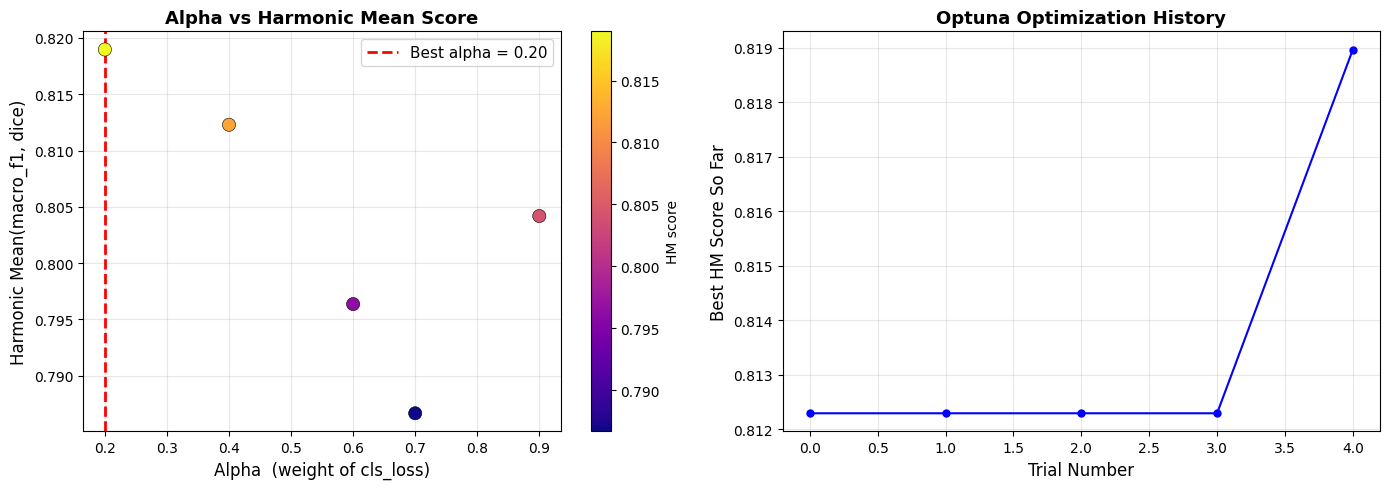

/content/drive/MyDrive/medicine_/optuna_harmonic_analysis.png


In [18]:
if len(trials_done) > 1:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    sc = axes[0].scatter(
        trials_done["alpha"],
        trials_done["HM(f1,dice)"],
        c=trials_done["HM(f1,dice)"],
        cmap="plasma", s=90, zorder=3, edgecolors="k", linewidths=0.4
    )
    axes[0].axvline(BEST_ALPHA, color="red", linestyle="--", lw=2,
                    label=f"Best alpha = {BEST_ALPHA:.2f}")
    plt.colorbar(sc, ax=axes[0], label="HM score")
    axes[0].set_xlabel("Alpha  (weight of cls_loss)", fontsize=12)
    axes[0].set_ylabel("Harmonic Mean(macro_f1, dice)", fontsize=12)
    axes[0].set_title("Alpha vs Harmonic Mean Score", fontsize=13, fontweight="bold")
    axes[0].legend(fontsize=11)
    axes[0].grid(alpha=0.3)


    sorted_by_num = trials_done.sort_values("number")
    best_so_far   = np.maximum.accumulate(sorted_by_num["HM(f1,dice)"].values)
    axes[1].plot(sorted_by_num["number"].values, best_so_far,
                 "b-o", markersize=5, linewidth=1.5)
    axes[1].set_xlabel("Trial Number", fontsize=12)
    axes[1].set_ylabel("Best HM Score So Far", fontsize=12)
    axes[1].set_title("Optuna Optimization History", fontsize=13, fontweight="bold")
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig("/content/drive/MyDrive/medicine_real3/MyDriveoptuna_harmonic_analysis.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("/content/drive/MyDrive/medicine_/optuna_harmonic_analysis.png")

## 11. Final Training – Full 5-Fold với Best Alpha

In [19]:
FINAL_N_FOLDS  = 5
FINAL_N_EPOCHS = 80
FINAL_BATCH    = 16
FINAL_LR       = 3e-4
PATIENCE       = 15

print(f"\n{'='*65}")
print(f"  FINAL TRAINING CONFIG")
print(f"{'='*65}")
print(f"  Best alpha   : {BEST_ALPHA:.2f}")
print(f"  Seg loss     : {W_BCE_SEG}·BCE + {W_DICE_SEG}·Dice  (cố định)")
print(f"  Total loss   : {BEST_ALPHA:.2f}·cls + {1-BEST_ALPHA:.2f}·seg")
print(f"  Monitor      : val hm_score = Harmonic Mean(macro_f1, dice)")
print(f"  Patience     : {PATIENCE} epochs")
print(f"{'='*65}")


  FINAL TRAINING CONFIG
  Best alpha   : 0.20
  Seg loss     : 0.5·BCE + 0.5·Dice  (cố định)
  Total loss   : 0.20·cls + 0.80·seg
  Monitor      : val hm_score = Harmonic Mean(macro_f1, dice)
  Patience     : 15 epochs



─────────────────────────────────────────────────────────────────
  FOLD 1/5  │  alpha=0.20
─────────────────────────────────────────────────────────────────


config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/87.3M [00:00<?, ?B/s]

  Ep [ 1/80] Yes Loss=0.7293/0.8126  Dice=0.2685/0.2364  F1=0.5025/0.4272  HM=0.3500/0.3043


  Ep [ 2/80] Yes Loss=0.5653/0.5295  Dice=0.4302/0.4629  F1=0.6239/0.7379  HM=0.5093/0.5689


...

  Ep [27/80]    Loss=0.2498/0.2499  Dice=0.6801/0.7327  F1=0.8733/0.8327  HM=0.7647/0.7795


  Ep [28/80]    Loss=0.2109/0.2451  Dice=0.7312/0.7046  F1=0.8698/0.8832  HM=0.7945/0.7839


  Ep [29/80]    Loss=0.2340/0.2551  Dice=0.7464/0.7535  F1=0.8750/0.8808  HM=0.8056/0.8122


  Ep [30/80]    Loss=0.2072/0.2444  Dice=0.7588/0.7513  F1=0.8982/0.8361  HM=0.8226/0.7914
 Early stopping at 30
 Best model updated! HM = 0.8264



  Fold 1 | Loss=0.2372  Dice=0.7791  F1=0.8800  HM=0.8264


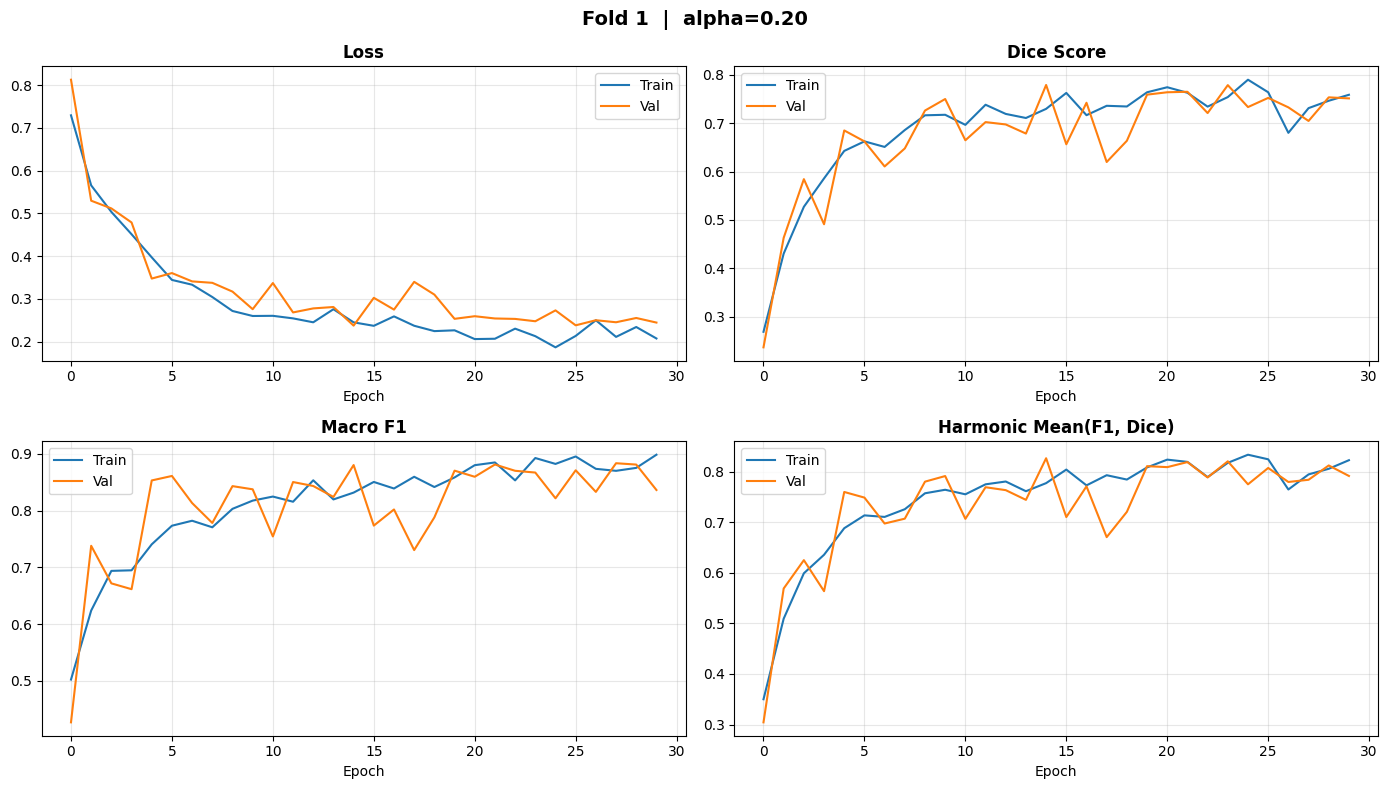


─────────────────────────────────────────────────────────────────
  FOLD 2/5  │  alpha=0.20
─────────────────────────────────────────────────────────────────


  Ep [ 1/80] Yes Loss=0.6396/0.8116  Dice=0.3405/0.3043  F1=0.4361/0.5672  HM=0.3824/0.3961


  Ep [ 2/80] Yes Loss=0.4864/0.4906  Dice=0.5518/0.4794  F1=0.7062/0.6536  HM=0.6195/0.5531


  Ep [ 3/80] Yes Loss=0.4140/0.4736  Dice=0.6136/0.5044  F1=0.7317/0.7066  HM=0.6675/0.5886


  Ep [ 4/80] Yes Loss=0.3593/0.3740  Dice=0.6444/0.6141  F1=0.7475/0.7727  HM=0.6921/0.6843


...

  Ep [49/80]    Loss=0.1178/0.2342  Dice=0.8380/0.7683  F1=0.9464/0.8631  HM=0.8889/0.8129


  Ep [50/80]    Loss=0.1107/0.2576  Dice=0.8541/0.7659  F1=0.9660/0.8934  HM=0.9066/0.8248


  Ep [51/80]    Loss=0.1083/0.2303  Dice=0.8570/0.7655  F1=0.9752/0.8878  HM=0.9123/0.8221


  Ep [52/80]    Loss=0.1130/0.2664  Dice=0.8476/0.7669  F1=0.9666/0.8705  HM=0.9032/0.8155
 Early stopping at 52
 Best model updated! HM = 0.8327



  Fold 2 | Loss=0.2131  Dice=0.7893  F1=0.8811  HM=0.8327


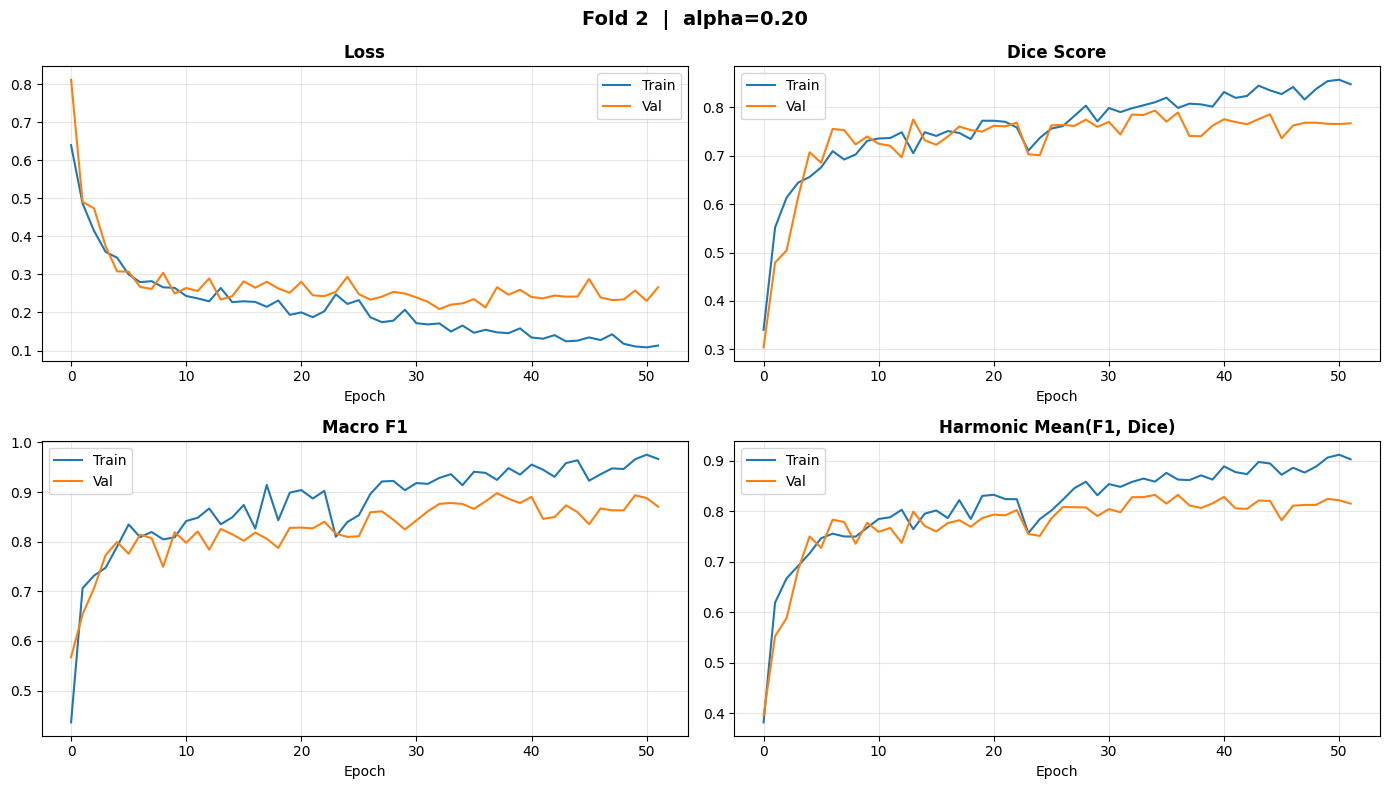


─────────────────────────────────────────────────────────────────
  FOLD 3/5  │  alpha=0.20
─────────────────────────────────────────────────────────────────


  Ep [ 1/80] Yes Loss=0.6010/0.5103  Dice=0.3004/0.4004  F1=0.4887/0.6294  HM=0.3721/0.4894


  Ep [ 2/80]    Loss=0.4468/0.6063  Dice=0.5631/0.3826  F1=0.6963/0.5821  HM=0.6226/0.4617


  Ep [ 3/80] Yes Loss=0.3528/0.4219  Dice=0.6412/0.5085  F1=0.7779/0.7116  HM=0.7029/0.5932


  Ep [ 4/80]    Loss=0.3465/0.4579  Dice=0.6410/0.5124  F1=0.7378/0.5696  HM=0.6860/0.5395


...

  Ep [59/80]    Loss=0.1077/0.3088  Dice=0.8542/0.7418  F1=0.9576/0.8258  HM=0.9029/0.7815


  Ep [60/80]    Loss=0.1011/0.3080  Dice=0.8659/0.7402  F1=0.9790/0.8191  HM=0.9190/0.7777


  Ep [61/80]    Loss=0.0941/0.2805  Dice=0.8668/0.7591  F1=0.9753/0.8398  HM=0.9179/0.7974


  Ep [62/80]    Loss=0.0909/0.3153  Dice=0.8674/0.7433  F1=0.9664/0.8396  HM=0.9142/0.7885
 Early stopping at 62



  Fold 3 | Loss=0.2483  Dice=0.7699  F1=0.8569  HM=0.8111


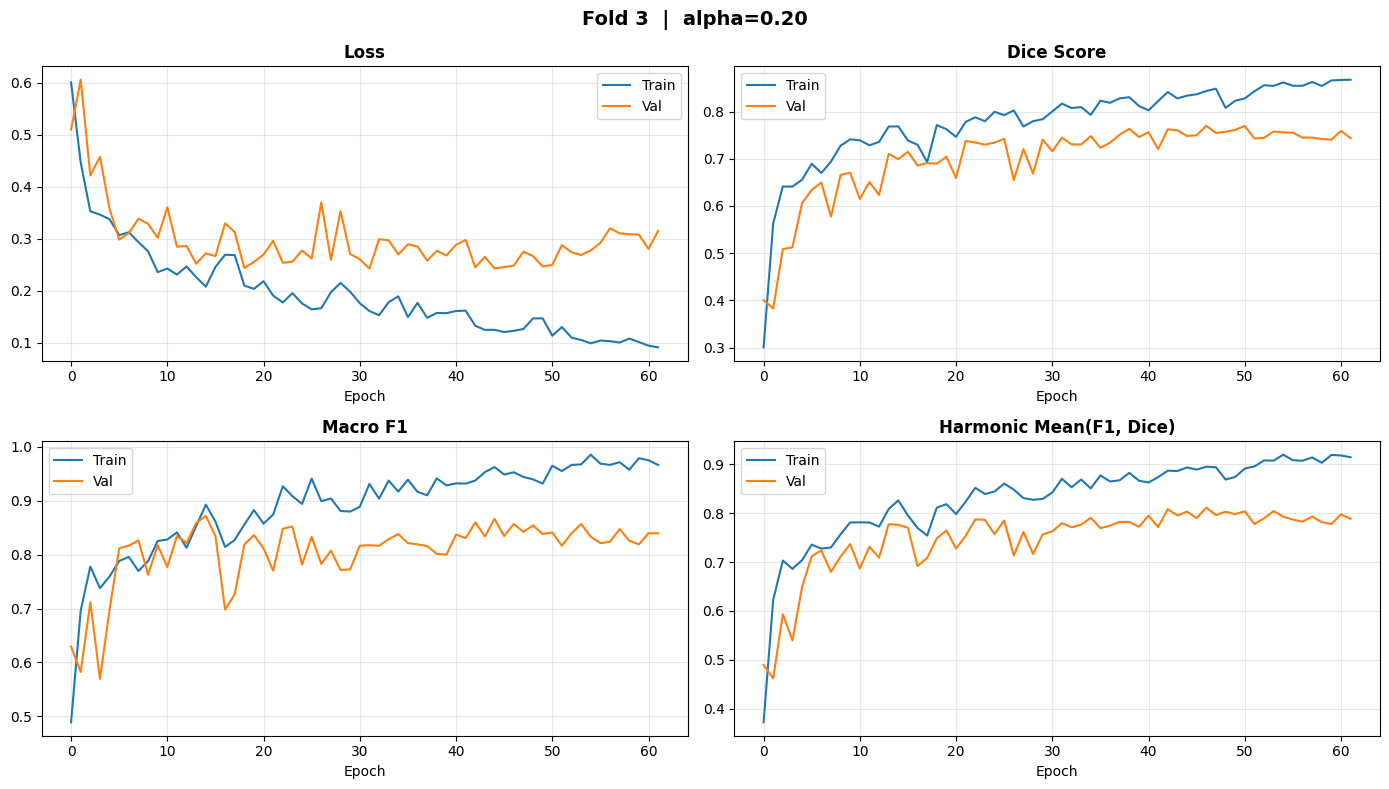


─────────────────────────────────────────────────────────────────
  FOLD 4/5  │  alpha=0.20
─────────────────────────────────────────────────────────────────


  Ep [ 1/80] Yes Loss=0.6422/0.6292  Dice=0.2981/0.3860  F1=0.4196/0.5364  HM=0.3486/0.4489


  Ep [ 2/80] Yes Loss=0.4594/0.4226  Dice=0.5193/0.6218  F1=0.6799/0.7485  HM=0.5889/0.6793


  Ep [ 3/80] Yes Loss=0.4041/0.3233  Dice=0.6070/0.6469  F1=0.6832/0.7877  HM=0.6429/0.7104


  Ep [ 4/80]    Loss=0.3369/0.3686  Dice=0.6441/0.6269  F1=0.7498/0.7469  HM=0.6929/0.6816


...

  Ep [26/80]    Loss=0.1911/0.2722  Dice=0.7818/0.7632  F1=0.9070/0.7695  HM=0.8398/0.7663


  Ep [27/80]    Loss=0.1713/0.2735  Dice=0.7897/0.7713  F1=0.9122/0.8397  HM=0.8465/0.8041


  Ep [28/80]    Loss=0.1731/0.2992  Dice=0.7814/0.7791  F1=0.8938/0.8071  HM=0.8338/0.7929


  Ep [29/80]    Loss=0.2255/0.2358  Dice=0.7301/0.7546  F1=0.8361/0.8530  HM=0.7795/0.8008
 Early stopping at 29



  Fold 4 | Loss=0.2343  Dice=0.7742  F1=0.8582  HM=0.8140


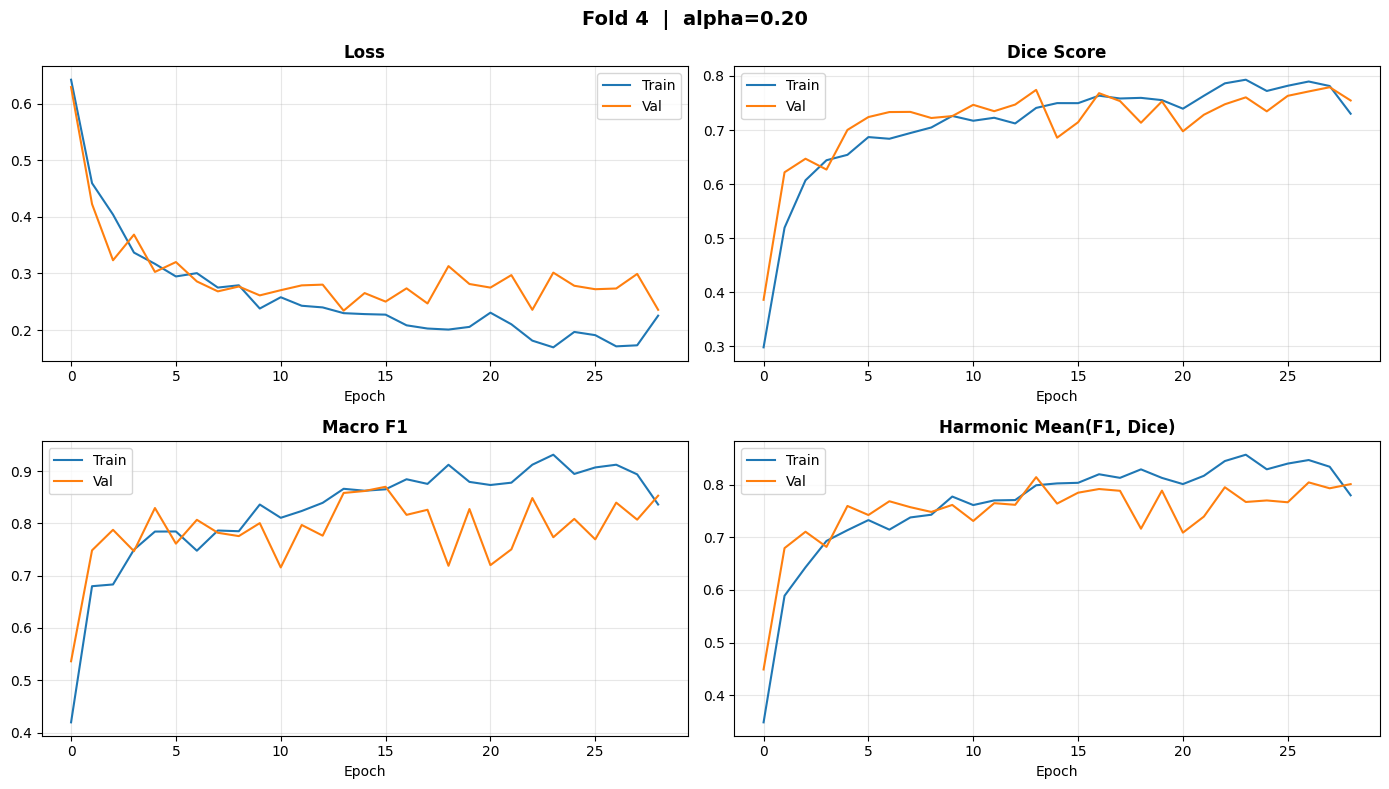


─────────────────────────────────────────────────────────────────
  FOLD 5/5  │  alpha=0.20
─────────────────────────────────────────────────────────────────


  Ep [ 1/80] Yes Loss=0.6329/1.5643  Dice=0.3240/0.2461  F1=0.5271/0.4744  HM=0.4013/0.3241


  Ep [ 2/80] Yes Loss=0.4567/0.4281  Dice=0.5764/0.6080  F1=0.6884/0.6131  HM=0.6275/0.6106


  Ep [ 3/80] Yes Loss=0.3680/0.4221  Dice=0.6514/0.5996  F1=0.7820/0.6907  HM=0.7108/0.6419


  Ep [ 4/80] Yes Loss=0.3532/0.3230  Dice=0.6655/0.6770  F1=0.7367/0.7367  HM=0.6993/0.7056


...

  Ep [38/80]    Loss=0.1612/0.1883  Dice=0.8103/0.8129  F1=0.9170/0.8500  HM=0.8603/0.8311


  Ep [39/80]    Loss=0.1382/0.1772  Dice=0.8164/0.8007  F1=0.9279/0.8263  HM=0.8686/0.8133


  Ep [40/80]    Loss=0.1595/0.1684  Dice=0.8072/0.8059  F1=0.9296/0.8805  HM=0.8641/0.8415


  Ep [41/80]    Loss=0.1604/0.1720  Dice=0.8074/0.7951  F1=0.9319/0.8557  HM=0.8652/0.8243
 Early stopping at 41
 Best model updated! HM = 0.8423



  Fold 5 | Loss=0.1825  Dice=0.7996  F1=0.8899  HM=0.8423


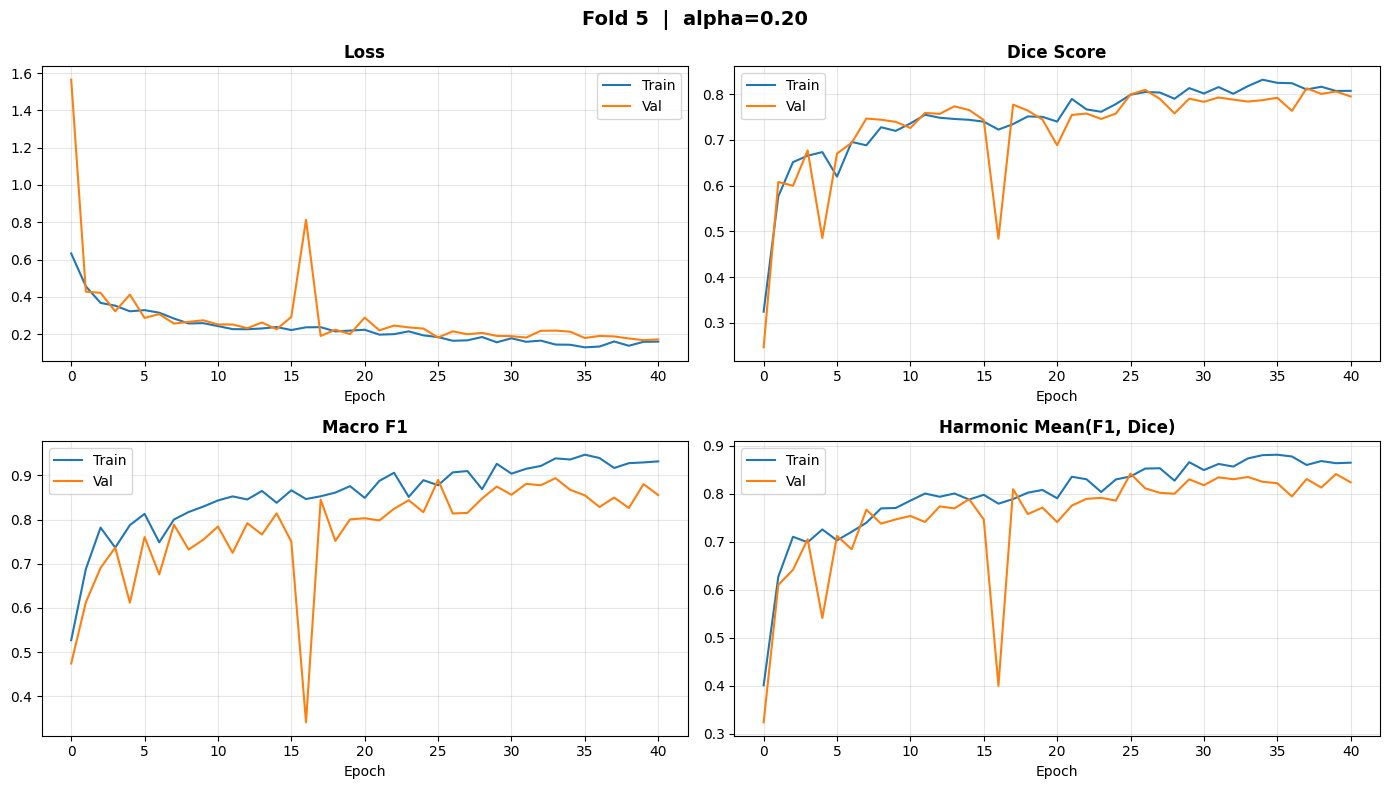

In [18]:
BEST_ALPHA = 0.2

skf_final      = StratifiedKFold(n_splits=FINAL_N_FOLDS, shuffle=True, random_state=42)
fold_results   = []
best_val_hm    = -np.inf
best_model_wts = None

bce_fn = nn.BCEWithLogitsLoss()
ce_fn  = nn.CrossEntropyLoss()

for fold, (train_idx, val_idx) in enumerate(
    skf_final.split(train_val_df, train_val_df["class_id"])
):
    print(f"\n{'─'*65}")
    print(f"  FOLD {fold+1}/{FINAL_N_FOLDS}  │  alpha={BEST_ALPHA:.2f}")
    print(f"{'─'*65}")

    train_fold = train_val_df.iloc[train_idx].reset_index(drop=True)
    val_fold   = train_val_df.iloc[val_idx].reset_index(drop=True)

    train_loader = DataLoader(
        BUSIMultiTaskDataset(train_fold, train_tfms),
        batch_size=FINAL_BATCH, shuffle=True, num_workers=2, pin_memory=True
    )
    val_loader = DataLoader(
        BUSIMultiTaskDataset(val_fold, valid_tfms),
        batch_size=FINAL_BATCH, shuffle=False, num_workers=2, pin_memory=True
    )

    model     = MultiTaskUNet().to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=FINAL_LR, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=FINAL_N_EPOCHS, eta_min=1e-6
    )

    fold_best_hm  = -np.inf
    fold_best_wts = None
    no_improve    = 0

    history = {k: [] for k in
               ["t_loss","v_loss","t_dice","v_dice","t_f1","v_f1","t_hm","v_hm"]}

    for epoch in range(FINAL_N_EPOCHS):
        t = run_epoch(model, train_loader, optimizer=optimizer, train=True,
                      alpha=BEST_ALPHA, bce_fn=bce_fn, ce_fn=ce_fn)
        v = run_epoch(model, val_loader,   optimizer=None,      train=False,
                      alpha=BEST_ALPHA, bce_fn=bce_fn, ce_fn=ce_fn)
        scheduler.step()

        for key, val in zip(
            ["t_loss","v_loss","t_dice","v_dice","t_f1","v_f1","t_hm","v_hm"],
            [t["loss"],v["loss"],t["dice"],v["dice"],t["macro_f1"],v["macro_f1"],
             t["hm_score"],v["hm_score"]]
        ):
            history[key].append(val)

        flag = "Yes" if v["hm_score"] > fold_best_hm else "  "
        print(f"  Ep [{epoch+1:>2}/{FINAL_N_EPOCHS}] {flag} "
              f"Loss={t['loss']:.4f}/{v['loss']:.4f}  "
              f"Dice={t['dice']:.4f}/{v['dice']:.4f}  "
              f"F1={t['macro_f1']:.4f}/{v['macro_f1']:.4f}  "
              f"HM={t['hm_score']:.4f}/{v['hm_score']:.4f}")

        if v["hm_score"] > fold_best_hm:
            fold_best_hm  = v["hm_score"]
            fold_best_wts = {k: v2.clone() for k, v2 in model.state_dict().items()}
            no_improve    = 0
        else:
            no_improve += 1
            if no_improve >= PATIENCE:
                print(f" Early stopping at {epoch+1}")
                break

    if fold_best_hm > best_val_hm:
        best_val_hm    = fold_best_hm
        best_model_wts = fold_best_wts
        print(f" Best model updated! HM = {best_val_hm:.4f}")


    model.load_state_dict(fold_best_wts)
    with torch.no_grad():
        fv = run_epoch(model, val_loader, optimizer=None, train=False,
                       alpha=BEST_ALPHA, bce_fn=bce_fn, ce_fn=ce_fn)

    fold_results.append({
        "fold":     fold + 1,
        "val_loss": fv["loss"],
        "val_dice": fv["dice"],
        "val_iou":  fv["iou"],
        "val_acc":  fv["acc"],
        "val_f1":   fv["macro_f1"],
        "val_hm":   fv["hm_score"],
    })

    print(f"\n  Fold {fold+1} | "
          f"Loss={fv['loss']:.4f}  Dice={fv['dice']:.4f}  "
          f"F1={fv['macro_f1']:.4f}  HM={fv['hm_score']:.4f}")

    fig, axes = plt.subplots(2, 2, figsize=(14, 8))
    pairs = [
        ("t_loss","v_loss",  "Loss"),
        ("t_dice","v_dice",  "Dice Score"),
        ("t_f1",  "v_f1",    "Macro F1"),
        ("t_hm",  "v_hm",    "Harmonic Mean(F1, Dice)"),
    ]
    for ax, (tk, vk, title) in zip(axes.flat, pairs):
        ax.plot(history[tk], label="Train", linewidth=1.5)
        ax.plot(history[vk], label="Val",   linewidth=1.5)
        ax.set_title(title, fontweight="bold")
        ax.set_xlabel("Epoch")
        ax.legend()
        ax.grid(alpha=0.3)
    plt.suptitle(f"Fold {fold+1}  |  alpha={BEST_ALPHA:.2f}",
                 fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.savefig(f"/content/drive/MyDrive/medicine_real3/fold{fold+1}_curves.png", dpi=120, bbox_inches="tight")
    plt.show()

    del model
    torch.cuda.empty_cache()

In [19]:
results_df = pd.DataFrame(fold_results)
mean_row   = results_df.mean(numeric_only=True).to_dict(); mean_row["fold"] = "Mean"
std_row    = results_df.std(numeric_only=True).to_dict();  std_row["fold"]  = "Std"
results_df = pd.concat(
    [results_df, pd.DataFrame([mean_row, std_row])],
    ignore_index=True
)

print(f"\n{'='*65}")
print(f"  RESULTS OF 5-FOLD CV  (alpha={BEST_ALPHA:.2f})")
print(f"{'='*65}")
display(results_df.round(4))


  RESULTS OF 5-FOLD CV  (alpha=0.20)


,fold,val_loss,val_dice,val_iou,val_acc,val_f1,val_hm
0,1,0.2372,0.7791,0.7070,0.8872,0.8800,0.8264
1,2,0.2131,0.7893,0.7243,0.8797,0.8811,0.8327
2,3,0.2483,0.7699,0.7068,0.8647,0.8569,0.8111
3,4,0.2343,0.7742,0.7048,0.8636,0.8582,0.8140
4,5,0.1825,0.7996,0.7337,0.9015,0.8899,0.8423
5,Mean,0.2231,0.7824,0.7153,0.8793,0.8732,0.8253
6,Std,0.0261,0.0120,0.0130,0.0159,0.0148,0.0130


## 12. Test Set Evaluation

In [20]:
best_model = MultiTaskUNet().to(device)
best_model.load_state_dict(best_model_wts)
best_model.eval()

test_ds     = BUSIMultiTaskDataset(test_df, transforms=valid_tfms)
test_loader = DataLoader(test_ds, batch_size=FINAL_BATCH, shuffle=False,
                         num_workers=2, pin_memory=True)

bce_fn = nn.BCEWithLogitsLoss()
ce_fn  = nn.CrossEntropyLoss()

with torch.no_grad():
    test_m = run_epoch(
        best_model, test_loader, optimizer=None, train=False,
        alpha=BEST_ALPHA, bce_fn=bce_fn, ce_fn=ce_fn
    )

print(f"\n{'='*65}")
print(f"  KẾT QUẢ TEST SET  (alpha={BEST_ALPHA:.2f})")
print(f"{'='*65}")
for k, v in test_m.items():
    print(f"  {k.upper():<14}: {v:.4f}")


  KẾT QUẢ TEST SET  (alpha=0.20)
  LOSS          : 0.2156
  SEG_LOSS      : 0.2061
  CLS_LOSS      : 0.2534
  DICE          : 0.7396
  IOU           : 0.6685
  ACC           : 0.9402
  MACRO_F1      : 0.9322
  HM_SCORE      : 0.8248



CLASSIFICATION REPORT – TEST SET
              precision    recall  f1-score   support

      normal     1.0000    0.8500    0.9189        20
      benign     0.9545    0.9545    0.9545        66
   malignant     0.8824    0.9677    0.9231        31

    accuracy                         0.9402       117
   macro avg     0.9456    0.9241    0.9322       117
weighted avg     0.9432    0.9402    0.9401       117



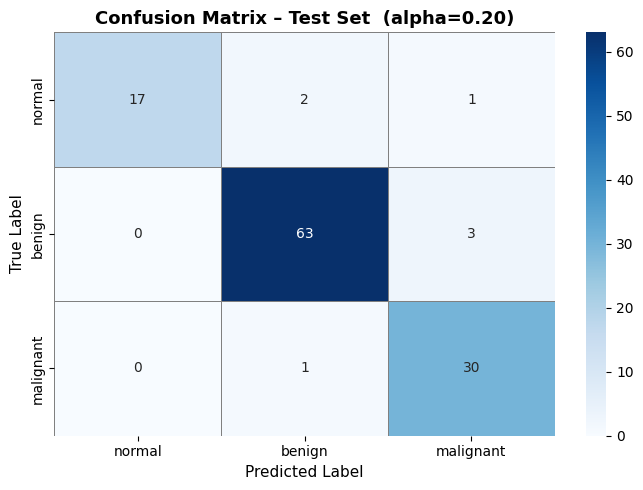

In [21]:
all_preds  = []
all_labels = []

best_model.eval()
with torch.no_grad():
    for images, masks, labels in tqdm(test_loader, desc="Collecting preds"):
        images = images.to(device)
        _, cls_logits = best_model(images)
        preds = torch.argmax(cls_logits, dim=1)
        all_preds.extend(preds.cpu().numpy().tolist())
        all_labels.extend(labels.numpy().tolist())

id_to_class = {0: "normal", 1: "benign", 2: "malignant"}

print("\nCLASSIFICATION REPORT – TEST SET")
print(classification_report(
    all_labels, all_preds,
    target_names=[id_to_class[i] for i in range(3)],
    digits=4
))

cm    = confusion_matrix(all_labels, all_preds)
cm_df = pd.DataFrame(
    cm,
    index=[id_to_class[i]   for i in range(3)],
    columns=[id_to_class[i] for i in range(3)]
)

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(cm_df, annot=True, fmt="d", cmap="Blues", ax=ax,
            linewidths=0.5, linecolor="gray")
ax.set_title(f"Confusion Matrix – Test Set  (alpha={BEST_ALPHA:.2f})",
             fontsize=13, fontweight="bold")
ax.set_ylabel("True Label", fontsize=11)
ax.set_xlabel("Predicted Label", fontsize=11)
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/medicine_real3/confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

## 13. ROC-AUC Curve

ROC probs: 100%|██████████| 8/8 [00:00<00:00,  8.73it/s]


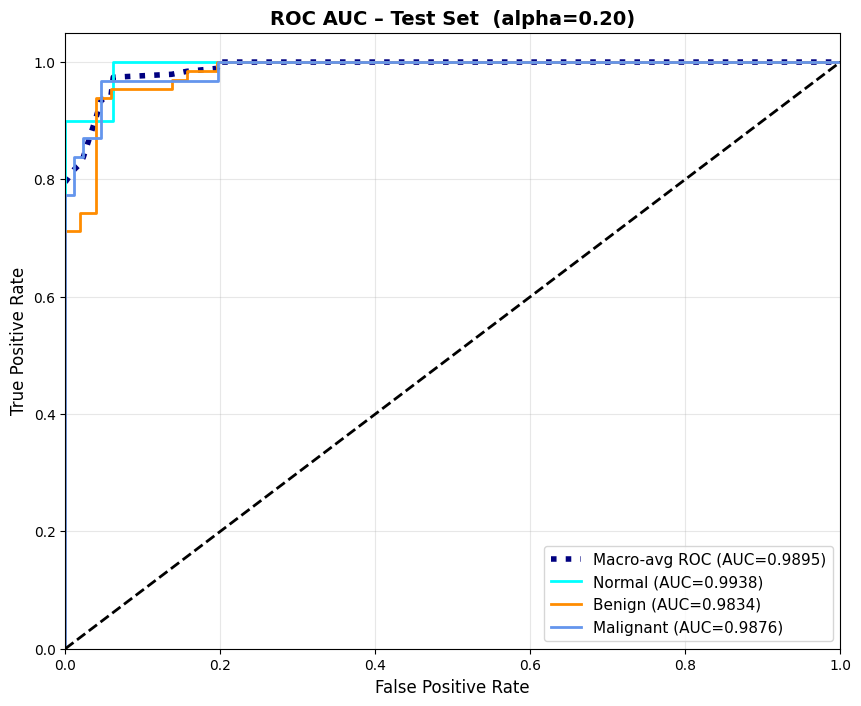

In [22]:
all_probs      = []
all_labels_roc = []

best_model.eval()
with torch.no_grad():
    for images, masks, labels in tqdm(test_loader, desc="ROC probs"):
        images = images.to(device)
        _, cls_logits = best_model(images)
        probs = torch.softmax(cls_logits, dim=1)
        all_probs.extend(probs.cpu().numpy().tolist())
        all_labels_roc.extend(labels.numpy().tolist())

y_test_bin = label_binarize(all_labels_roc, classes=[0, 1, 2])
y_score    = np.array(all_probs)
n_classes  = 3

fpr, tpr, roc_auc = {}, {}, {}
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc[i]        = auc(fpr[i], tpr[i])

all_fpr  = np.unique(np.concatenate([fpr[i] for i in range(n_classes)]))
mean_tpr = sum(np.interp(all_fpr, fpr[i], tpr[i]) for i in range(n_classes)) / n_classes
fpr["macro"]     = all_fpr
tpr["macro"]     = mean_tpr
roc_auc["macro"] = auc(all_fpr, mean_tpr)

id_to_class = {0: "Normal", 1: "Benign", 2: "Malignant"}
colors      = ["aqua", "darkorange", "cornflowerblue"]

plt.figure(figsize=(10, 8))
plt.plot(fpr["macro"], tpr["macro"],
         label=f'Macro-avg ROC (AUC={roc_auc["macro"]:.4f})',
         color="navy", linestyle=":", linewidth=4)
for i, c in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=c, lw=2,
             label=f'{id_to_class[i]} (AUC={roc_auc[i]:.4f})')
plt.plot([0, 1], [0, 1], "k--", lw=2)
plt.xlim([0, 1]); plt.ylim([0, 1.05])
plt.xlabel("False Positive Rate", fontsize=12)
plt.ylabel("True Positive Rate",  fontsize=12)
plt.title(f"ROC AUC – Test Set  (alpha={BEST_ALPHA:.2f})",
          fontsize=14, fontweight="bold")
plt.legend(loc="lower right", fontsize=11)
plt.grid(alpha=0.3)
plt.savefig("/content/drive/MyDrive/medicine_real3/roc_auc.png", dpi=150, bbox_inches="tight")
plt.show()

## 14. Sample

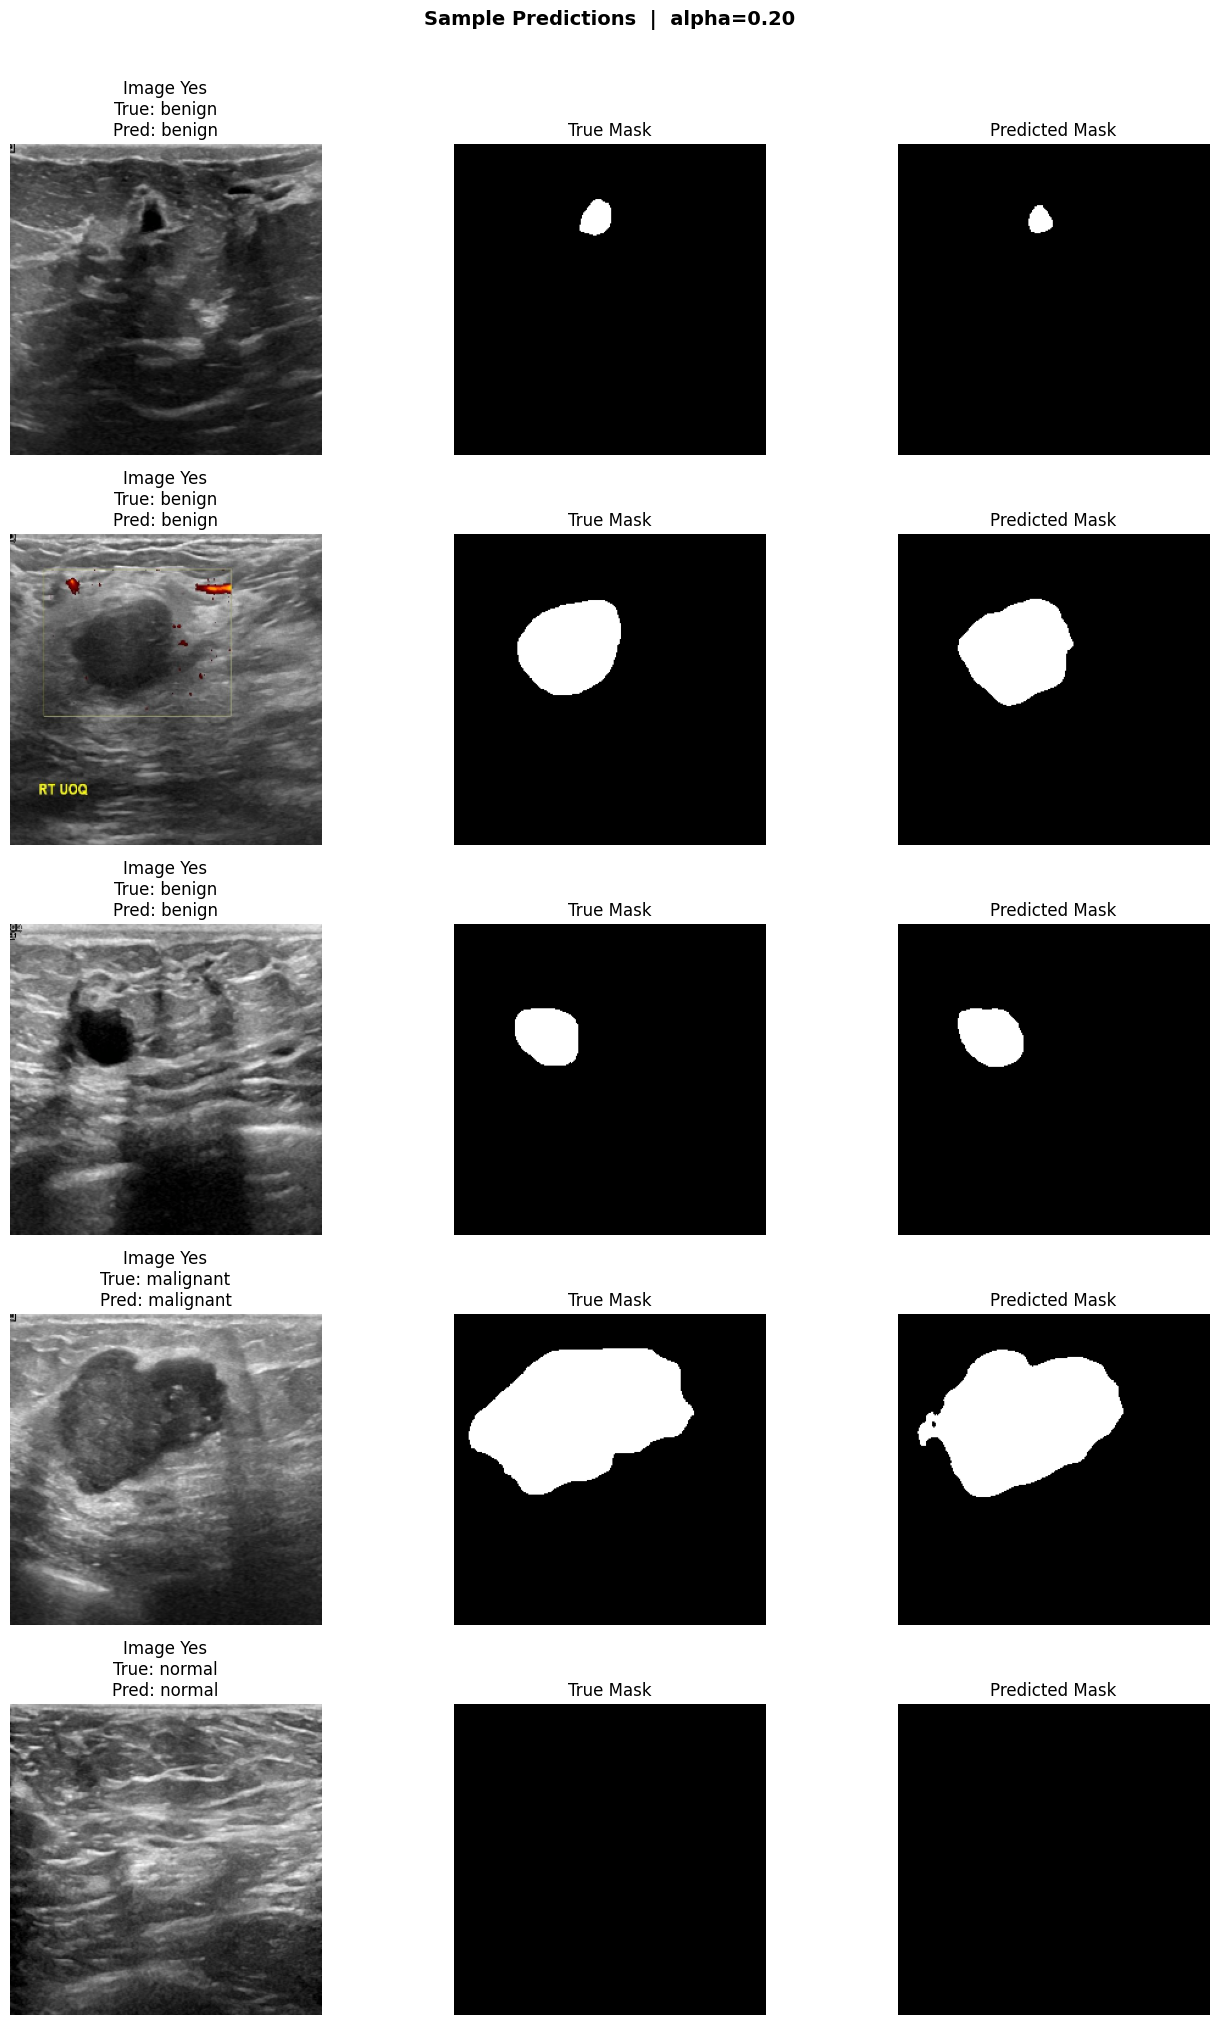

In [23]:
def denorm_image(x):
    mean = np.array([0.485, 0.456, 0.406], dtype=np.float32)
    std  = np.array([0.229, 0.224, 0.225], dtype=np.float32)
    return np.clip(x * std + mean, 0, 1)

def show_predictions(dataset, model, num_samples=5):
    model.eval()
    indices     = np.random.choice(len(dataset), num_samples, replace=False)
    id_to_class = {0: "normal", 1: "benign", 2: "malignant"}

    plt.figure(figsize=(14, 4 * num_samples))
    for i, idx in enumerate(indices):
        image, mask, label = dataset[idx]
        with torch.no_grad():
            seg_logits, cls_logits = model(image.unsqueeze(0).to(device))
            pred_mask  = (torch.sigmoid(seg_logits)[0, 0].cpu().numpy() > 0.5).astype(np.uint8)
            pred_cls   = torch.argmax(cls_logits, dim=1).item()

        img_np    = denorm_image(image.permute(1, 2, 0).cpu().numpy())
        true_mask = mask[0].cpu().numpy()
        match     = "Yes" if pred_cls == label.item() else "No"

        plt.subplot(num_samples, 3, 3*i+1)
        plt.imshow(img_np)
        plt.title(f"Image {match}\nTrue: {id_to_class[label.item()]}\nPred: {id_to_class[pred_cls]}")
        plt.axis("off")

        plt.subplot(num_samples, 3, 3*i+2)
        plt.imshow(true_mask, cmap="gray")
        plt.title("True Mask")
        plt.axis("off")

        plt.subplot(num_samples, 3, 3*i+3)
        plt.imshow(pred_mask, cmap="gray")
        plt.title("Predicted Mask")
        plt.axis("off")

    plt.suptitle(f"Sample Predictions  |  alpha={BEST_ALPHA:.2f}",
                 fontsize=14, fontweight="bold", y=1.01)
    plt.tight_layout()
    plt.savefig("/content/drive/MyDrive/medicine_real3/sample_predictions.png", dpi=120, bbox_inches="tight")
    plt.show()

show_predictions(test_ds, best_model, num_samples=5)

## 15. Summary

In [25]:
fold_only   = pd.DataFrame(fold_results)
metric_cols = ["val_loss", "val_dice", "val_iou", "val_acc", "val_f1", "val_hm"]

print("\n" + "═"*65)
print(" SUMMARY ")
print("═"*65)
print(f"  Architecture    : MultiTaskUNet  (ResNet34 encoder)")
print(f"  Seg loss (fixed): {W_BCE_SEG}·BCE + {W_DICE_SEG}·Dice")
print(f"  Best alpha      : {BEST_ALPHA:.2f}  (manual set)")
print(f"  Total loss      : {BEST_ALPHA:.2f}·cls_loss + {1-BEST_ALPHA:.2f}·seg_loss")
print("─"*65)
print("  5-FOLD VALIDATION (mean ± std):")
for col in metric_cols:
    m, s = fold_only[col].mean(), fold_only[col].std()
    print(f"    {col:<12}: {m:.4f} ± {s:.4f}")
print("─"*65)
print("  TEST SET:")
for k, v in test_m.items():
    print(f"    {k.upper():<14}: {v:.4f}")
print("═"*65)


═════════════════════════════════════════════════════════════════
 SUMMARY 
═════════════════════════════════════════════════════════════════
  Architecture    : MultiTaskUNet  (ResNet34 encoder)
  Seg loss (fixed): 0.5·BCE + 0.5·Dice
  Best alpha      : 0.20  (manual set)
  Total loss      : 0.20·cls_loss + 0.80·seg_loss
─────────────────────────────────────────────────────────────────
  5-FOLD VALIDATION (mean ± std):
    val_loss    : 0.2231 ± 0.0261
    val_dice    : 0.7824 ± 0.0120
    val_iou     : 0.7153 ± 0.0130
    val_acc     : 0.8793 ± 0.0159
    val_f1      : 0.8732 ± 0.0148
    val_hm      : 0.8253 ± 0.0130
─────────────────────────────────────────────────────────────────
  TEST SET:
    LOSS          : 0.2156
    SEG_LOSS      : 0.2061
    CLS_LOSS      : 0.2534
    DICE          : 0.7396
    IOU           : 0.6685
    ACC           : 0.9402
    MACRO_F1      : 0.9322
    HM_SCORE      : 0.8248
═════════════════════════════════════════════════════════════════


In [26]:
import pickle

torch.save({
    "model_state_dict": best_model_wts,
    "best_alpha":       BEST_ALPHA,
    "test_metrics":     test_m,
    "fold_results":     fold_results,
}, "/content/drive/MyDrive/medicine_real3/best_model_harmonic.pth")

print("best_model_harmonic.pth")

best_model_harmonic.pth
